In [1]:
import pandas as pd    ##data handling
import numpy          ##numerical python  in mathematical calc
from sklearn import svm      ## proving us regarding algorithm
from sklearn.linear_model import LogisticRegression
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
data = pd.read_csv('data_arrhythmia.csv')

In [3]:
data.head()

,Age,Sex,Height,Weight,qrs,p_r,q_t,t,p,qrss,...,KY,KZ,LA,LB,LC,LD,LE,LF,LG,diagnosis
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0,-0.1,3.9,25.4,62.8,7


In [4]:
#data.replace('?', np.nan, inplace=True)
#data = data.dropna()  # or fillna(method='ffill')


In [5]:
data["diagnosis"].unique()

array([ 8,  6, 10,  1,  7, 14,  3, 16,  2,  4,  5,  9, 15], dtype=int64)

In [6]:
len(data["diagnosis"].unique())

13

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1356 entries, 0 to 1355
Columns: 280 entries, Age to diagnosis
dtypes: float64(121), int64(159)
memory usage: 2.9 MB


In [8]:
data.describe()

,Age,Sex,Height,Weight,qrs,p_r,q_t,t,p,qrss,...,KY,KZ,LA,LB,LC,LD,LE,LF,LG,diagnosis
count,1356.000000,1356.000000,1356.000000,1356.000000,1356.000000,1356.000000,1356.000000,1356.000000,1356.000000,1356.000000,...,1356.000000,1356.000000,1356.000000,1356.000000,1356.0,1356.000000,1356.000000,1356.000000,1356.000000,1356.000000
mean,46.471239,0.550885,166.188053,68.170354,88.920354,155.152655,367.207965,169.949115,90.004425,33.676991,...,-0.278982,9.048009,-1.457301,0.003982,0.0,0.514823,1.222345,19.326106,29.473230,3.880531
std,16.454474,0.497587,37.142898,16.578554,15.353051,44.809176,33.360774,35.606765,25.807576,45.397893,...,0.548471,3.470298,2.000951,0.050081,0.0,0.347274,1.424999,13.493952,18.480273,4.403843
min,0.000000,0.000000,105.000000,6.000000,55.000000,0.000000,232.000000,108.000000,0.000000,-172.000000,...,-4.100000,0.000000,-28.600000,0.000000,0.0,-0.800000,-6.000000,-44.200000,-38.600000,1.000000
25%,36.000000,0.000000,160.000000,59.000000,80.000000,142.000000,350.000000,148.000000,79.000000,3.750000,...,-0.425000,6.600000,-2.100000,0.000000,0.0,0.400000,0.500000,11.450000,17.550000,1.000000
50%,47.000000,1.000000,164.000000,68.000000,86.000000,157.000000,367.000000,162.000000,91.000000,40.000000,...,0.000000,8.800000,-1.100000,0.000000,0.0,0.500000,1.350000,18.100000,27.900000,1.000000
75%,58.000000,1.000000,170.000000,79.000000,94.000000,175.000000,384.000000,179.000000,102.000000,66.000000,...,0.000000,11.200000,0.000000,0.000000,0.0,0.700000,2.100000,25.825000,41.125000,6.000000
max,83.000000,1.000000,780.000000,176.000000,188.000000,524.000000,509.000000,381.000000,205.000000,169.000000,...,0.000000,23.600000,0.000000,0.800000,0.0,2.400000,6.000000,88.800000,115.900000,16.000000


# PRE PROCESSING DATA (Removing Missing & NaN values)

In [9]:
data = data.fillna(data.mean())

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1356 entries, 0 to 1355
Columns: 280 entries, Age to diagnosis
dtypes: float64(121), int64(159)
memory usage: 2.9 MB


In [11]:
data.isnull().sum()

Age          0
Sex          0
Height       0
Weight       0
qrs          0
            ..
LD           0
LE           0
LF           0
LG           0
diagnosis    0
Length: 280, dtype: int64

In [12]:
X = data.iloc[:, :-1]
X = numpy.array(X)
X = X.astype(float)   # ✅ fixed

y = data.iloc[:, -1]
y = numpy.array(y)
y=y.astype(int)

# applying random forests to get pricipal attributes

In [13]:
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier

# Train model
model = ExtraTreesClassifier(random_state=42)
model.fit(X, y.ravel())

# Save feature importances
np.savetxt("randforrests.csv", model.feature_importances_, fmt='%s', delimiter=",")

# Select important features (threshold = 0.0045)
threshold = 0.0045
important_features_mask = model.feature_importances_ >= threshold

# Extract indices and importance values
important_features = model.feature_importances_[important_features_mask]
important_features_index = np.where(important_features_mask)[0]

print("Important features importance values:\n", important_features)
print("Important feature indices:\n", important_features_index)
print("Number of selected features =", len(important_features_index))

# Save selected feature indices
np.savetxt("import_features_index_after_random_forrests.csv", important_features_index, fmt='%d', delimiter=",")

# Create reduced feature matrix
newX = X[:, important_features_index]

print("Shape of reduced feature matrix:", newX.shape)

# Save reduced features
np.savetxt("reduced_features.csv", newX, fmt='%s', delimiter=",")


Important features importance values:
 [0.00624211 0.00605528 0.00459854 0.00842781 0.00462895 0.00796756
 0.00513492 0.00583983 0.0094441  0.005676   0.02025584 0.00533443
 0.00572443 0.0056952  0.00511379 0.00578035 0.00478952 0.0049427
 0.00482781 0.00486152 0.00578471 0.00496616 0.00507598 0.00456869
 0.00454963 0.00719521 0.00458705 0.00608425 0.02257574 0.02043996
 0.00511539 0.00671408 0.00467587 0.0100444  0.01238854 0.0069672
 0.01198115 0.00949281 0.00934717 0.0069317  0.00586579 0.00661243
 0.00509393 0.00544429 0.00529369 0.0052476  0.00477502 0.0054085
 0.00483194 0.00590919 0.00686837 0.00951774 0.0046245  0.00558319
 0.0055919  0.00589475 0.00564486 0.00519615 0.00913582 0.00540094
 0.0046737  0.00530517 0.00454501 0.00695071 0.00595519 0.0121253
 0.00456002 0.00572831 0.00514185 0.00684432 0.00943992 0.00487039
 0.00514522 0.00457936 0.00653895 0.01456133 0.00622534 0.00551125
 0.00724408 0.00457603 0.00837467 0.00456595 0.00518037 0.00630918
 0.00843774 0.00589274 0.00

In [14]:
x = pd.read_csv('reduced_features.csv')

In [15]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(x,y[:-1],test_size=0.2,random_state=100)

# KNN classifier

In [16]:
from sklearn.neighbors import KNeighborsClassifier
clf_KNN = KNeighborsClassifier(n_neighbors=13)

clf_KNN.fit(X_train,y_train)    ## fit ===> Training

KNeighborsClassifier(n_neighbors=13)

In [17]:
y_pred_knn  = clf_KNN.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_knn,y_test))
score_knn = accuracy_score(y_pred_knn,y_test)

0.5645756457564576


# SVM classifier 

In [19]:
clf_SVM = svm.SVC(C=1,kernel="linear")
clf_SVM.fit(X_train,y_train)

SVC(C=1, kernel='linear')

In [20]:
y_pred_svm  = clf_SVM.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_svm,y_test))
score_svm = accuracy_score(y_pred_svm,y_test)

0.974169741697417


# Logistic Regression

In [22]:

clf_LR = LogisticRegression(max_iter=100,C=1)
clf_LR.fit(X_train,y_train)

LogisticRegression(C=1)

In [23]:
y_pred_LR  = clf_LR.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_LR,y_test))
score_lr = accuracy_score(y_pred_LR,y_test)

0.5830258302583026


# Navie Bayes 

In [25]:
from sklearn.naive_bayes import GaussianNB
clf_NB = GaussianNB()
clf_NB.fit(X_train, y_train)

GaussianNB()

In [26]:
y_pred_NB = clf_NB.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_NB,y_test))
score_nb = accuracy_score(y_pred_NB,y_test)

0.11439114391143912


# Weigth KNN 

In [28]:
from sklearn.neighbors import KNeighborsClassifier
clf_WKNN = KNeighborsClassifier(n_neighbors=13,weights='distance')
clf_WKNN.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=13, weights='distance')

In [29]:
y_pred_WKNN = clf_WKNN.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_WKNN,y_test))
score_wknn = accuracy_score(y_pred_WKNN,y_test)

import pickle
with open('wknn_check.pkl', 'wb') as file:
   pickle.dump(clf_WKNN,file)


0.988929889298893


In [31]:
from sklearn.tree import DecisionTreeClassifier
DT= DecisionTreeClassifier()
DT.fit(X_train,y_train)

DecisionTreeClassifier()

In [32]:
scores = [score_knn,score_svm,score_lr,score_nb,score_wknn]
algorithms = ["KNN","Support Vector Machine","Logistic regression","naviebayes","Weigthed - knn"]    

for i in range(len(algorithms)):
    print(f"The accuracy score achieved using {algorithms[i]} is: {scores[i]*100:.2f} %")

The accuracy score achieved using KNN is: 56.46 %
The accuracy score achieved using Support Vector Machine is: 97.42 %
The accuracy score achieved using Logistic regression is: 58.30 %
The accuracy score achieved using naviebayes is: 11.44 %
The accuracy score achieved using Weigthed - knn is: 98.89 %


<Axes: xlabel='Algorithms', ylabel='Accuracy score'>

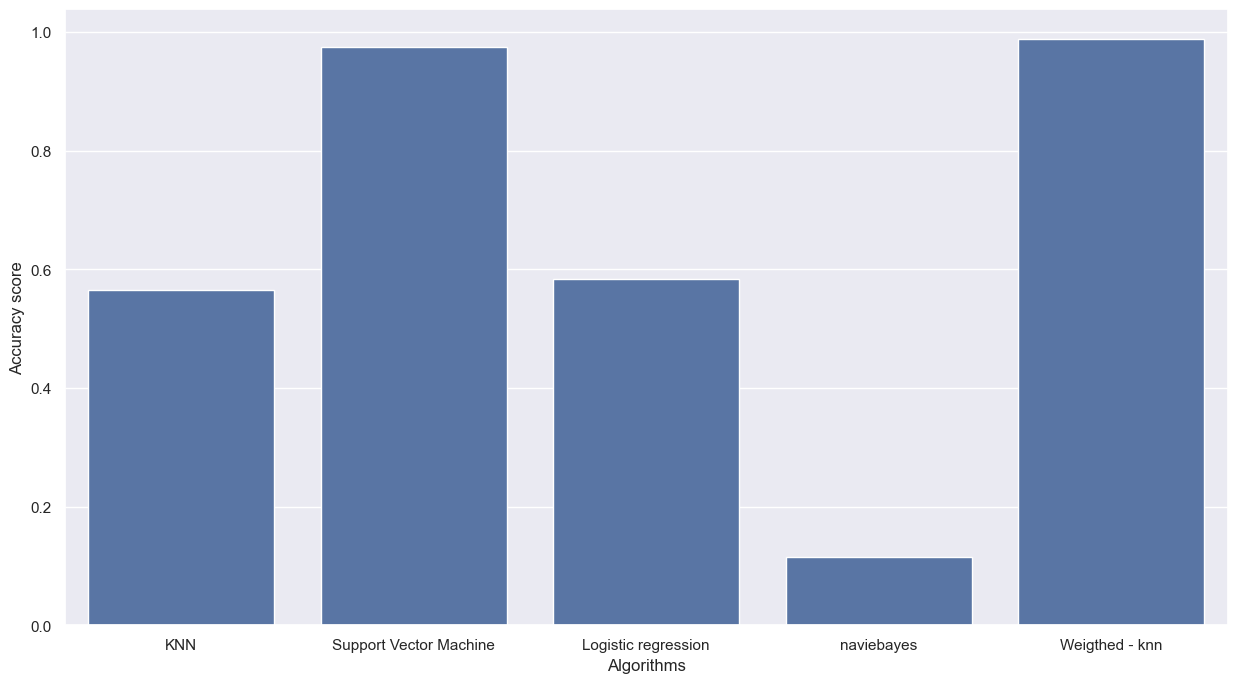

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(rc={'figure.figsize':(15,8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")
sns.barplot(x=algorithms,y=scores)

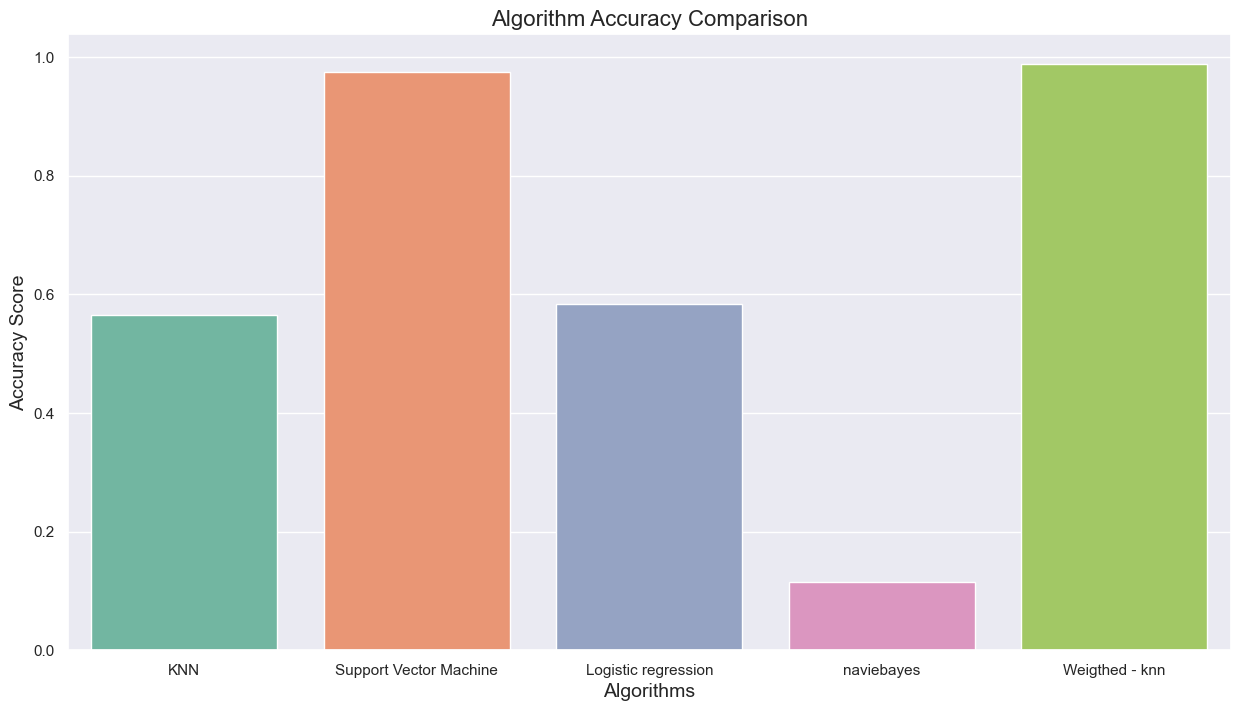

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt



# Set figure size
sns.set(rc={'figure.figsize': (15, 8)})

# Create colorful barplot
sns.barplot(x=algorithms, y=scores, palette="Set2")  # try "Set1", "Set2", "Paired", "Pastel1" etc.

# Add labels
plt.xlabel("Algorithms", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=14)
plt.title("Algorithm Accuracy Comparison", fontsize=16)

# Save the plot
plt.savefig("algorithm_accuracy.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()


In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [36]:
data['Sex'] = data['Sex'].map({'M': 0, 'F': 1})


In [37]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())


Cross-validation accuracy: 1.0


In [38]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model, {'n_estimators':[100,200,300],'max_depth':[5,10,15]}, cv=5)
grid.fit(X, y)
print(grid.best_params_)


{'max_depth': 15, 'n_estimators': 200}


<Axes: xlabel='diagnosis'>

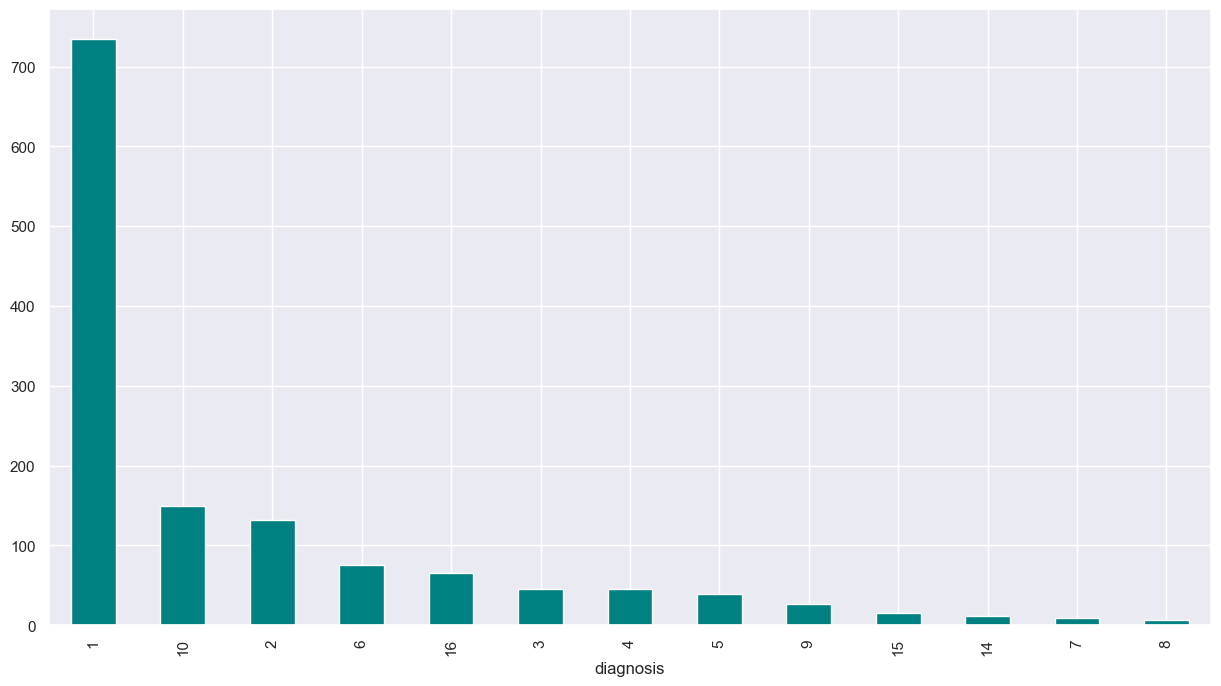

In [39]:
data['diagnosis'].value_counts().plot(kind='bar', color='teal')


In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

# Assuming you already have y_test and predictions like:
# y_pred_svm, y_pred_knn, y_pred_LR, y_pred_WKNN, y_pred_NB

models = {
    "SVM": (y_test, y_pred_svm),
    "KNN": (y_test, y_pred_knn),
    "Logistic Regression": (y_test, y_pred_LR),
    "Weighted-KNN": (y_test, y_pred_WKNN),
    "Naive Bayes": (y_test, y_pred_NB)
}

# Collect all metrics
results = []
for name, (y_true, y_pred) in models.items():
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    accuracy = accuracy_score(y_true, y_pred) * 100   # ✅ convert to percentage
    
    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Accuracy (%)": accuracy
    })

# Create a DataFrame
results_df = pd.DataFrame(results)

# Sort by Accuracy descending
results_df = results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

# Display as a formatted table
print("\n📊 Model Performance Comparison (sorted by Accuracy):\n")
print(results_df.to_string(index=False, formatters={
    "Precision": "{:.4f}".format,
    "Recall": "{:.4f}".format,
    "F1-Score": "{:.4f}".format,
    "Accuracy (%)": "{:.2f}".format
}))



📊 Model Performance Comparison (sorted by Accuracy):

              Model Precision Recall F1-Score Accuracy (%)
       Weighted-KNN    0.9891 0.9889   0.9887        98.89
                SVM    0.9744 0.9742   0.9732        97.42
Logistic Regression    0.5543 0.5830   0.5544        58.30
                KNN    0.4705 0.5646   0.4554        56.46
        Naive Bayes    0.6263 0.1144   0.1276        11.44
